In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

plt.rcParams["font.family"] = "Malgun Gothic" # 지수 마이너스가 나오는 폰트
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# scaler = MinMaxScaler()
# scaler.fit(X_train) # scaler.fit(X_test) 이거 절대 하지마

MinMaxScaler()

- svm은 minmax 많이 씀 (공간을 쓰는 건 minmax)
- 일반 선형은 안 됨

In [25]:
# KNN의 경우 거리를 이용해서 진행하기 때문에 minmax로 했을 때 사각형에 갇혀서 테두리에 달라붙는 값이 생기니까 standardScaler(평균, 분산 사용) 써야 함
# SVC의 경우에는 minmax로 1by1에 가둬서 차원을 변경시켜 어떻게든 특징을 나눔 => good

In [ ]:
# KNN에 Standard를 사용해서 스케일 조정 후에 학습을 진행하세요.
# 1. 데이터 => cancer 데이터
# 2. 데이터 나누기 => train/test
# 3. 스케일 = > standard
# 4. 학습 => fit, predict
# 5. 검증 => score..
# 6. pip freeze > requirements.txt

In [ ]:
cancer = load_breast_cancer()

# tip1. split 하기 전에 가능하면 분포를 확인하세요.
unique, counts = np.unique(cancer.target, return_counts=True)
for i, (val, count) in enumerate(zip(unique, counts)):
    print(f'{cancer.target_names[val]}: {count/len(cancer.target)}')

malignant: 0.37258347978910367
benign: 0.6274165202108963


In [49]:
# 분포가 한쪽에 쏠리면, stratify를 사용하여 균등하게 맞추세요. 과적합이 될 수 있지만 선택해야 함
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                    stratify=cancer.target,
                                                    random_state=42)

## load_breast_cancer()와 나이브 베이즈를 사용해서 최적의 스케일러는?

In [ ]:
scalers = {
    "None": None, # 안 하는 것도 스케일러에 포함
    "StandardScaler":StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

In [ ]:
scaling_results = {}
for name, scaler in scalers.items():
    if scaler is not None:
        X_train_scaler = scaler.fit_transform(X_train) # scaler = StandardScaler() 이거 안 해도 됨
        X_test_scaler = scaler.transform(X_test)
    else:
        X_train_scaler = X_train
        X_test_scaler = X_test

    gnb = GaussianNB()
    gnb.fit(X_train_scaler, y_train)

    y_pred = gnb.predict(X_test_scaler)
    accuracy = accuracy_score(y_test,y_pred)

    scaling_results[name] = {"accuracy": accuracy}

In [ ]:
scaling_results # 알고리즘을 선별하는 과정이었다.

{'None': {'accuracy': 0.9370629370629371},
 'StandardScaler': {'accuracy': 0.9370629370629371},
 'MinMaxScaler': {'accuracy': 0.9370629370629371}}

## KNN과 StandardScaler

In [85]:
# StandardScaler 스케일러 적용
scaler = StandardScaler()
scaler.fit(X_train) # fit_transform 가능하면 쓰지 마세요. 오류의 위험이 너무 많음
X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)
X_train_scaler.shape

(426, 30)

In [53]:
training_accuracy = []
test_accuracy = []
neighbors_settings = range(2, 31)

In [ ]:
for n_neighbors in neighbors_settings: # 파이프라인 하려면 이 반복문을 이해해야 함
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train_scaler, y_train)

    train_acc = knn.score(X_train_scaler, y_train)
    test_acc = knn.score(X_test_scaler, y_test)

    training_accuracy.append(train_acc)
    test_accuracy.append(test_acc)

In [57]:
best_k = neighbors_settings[np.argmax(test_accuracy)]
best_test_accuracy = max(test_accuracy)
best_k, best_test_accuracy # 짝수 나오면 폐기 # 어떤 인덱스에 어떤 값인지 확인

(5, 0.9790209790209791)

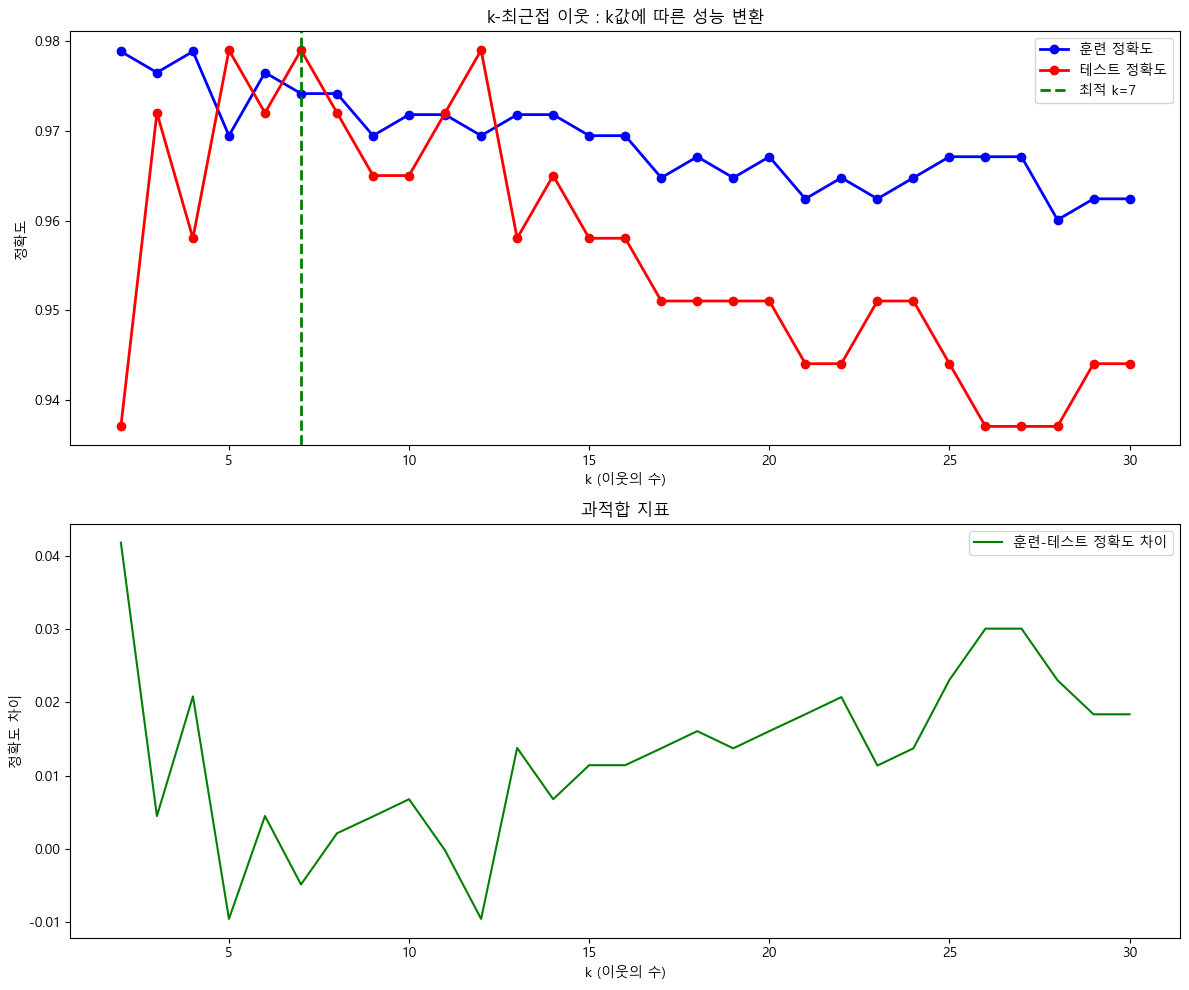

In [83]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,10))

# 정확도 곡선
ax1.plot(neighbors_settings, training_accuracy, "o-", label="훈련 정확도", linewidth=2, markersize=6, color="blue")
ax1.plot(neighbors_settings, test_accuracy, "o-", label="테스트 정확도", linewidth=2, markersize=6, color="red")
ax1.axvline(x=neighbors_settings[best_k], color="green", linestyle="--", linewidth=2, label=f"최적 k={neighbors_settings[best_k]}")
ax1.set_ylabel('정확도')
ax1.set_xlabel('k (이웃의 수)')
ax1.set_title("k-최근접 이웃 : k값에 따른 성능 변환")
ax1.legend() # label을 설정해줘야 이거 했을 때 뜨는 거임

# 정확도 차이
accuracy_diff = np.array(training_accuracy) - np.array(test_accuracy) # 판다스 못 쓸 때
ax2.plot(neighbors_settings, accuracy_diff, color="green", label="훈련-테스트 정확도 차이")
ax2.set_ylabel('정확도 차이')
ax2.set_xlabel('k (이웃의 수)')
ax2.set_title("과적합 지표")
ax2.legend()
plt.tight_layout()
plt.show()